# Final Notebook Conclusion

## Objective Achieved

A SARIMA forecasting model was successfully developed for hourly NYC taxi demand prediction.

## Analysis Performed

The following steps were completed:

- Time series preparation
- Stationarity testing using ADF
- Differencing to achieve stationarity
- Trend and seasonality analysis
- ACF and PACF analysis
- SARIMA parameter selection
- Train, validation, and test splitting
- Model training and forecasting
- Forecast accuracy evaluation
- Residual diagnostics
- Forecast error analysis

## Key Findings

- The demand series exhibited strong daily seasonality.
- The original series was non-stationary and required first-order differencing.
- SARIMA successfully captured trend and seasonal demand patterns.
- Residual analysis showed minimal remaining autocorrelation.
- Forecast errors were approximately normally distributed with a slight tendency toward underprediction.

## Model Assessment

The final SARIMA model demonstrated the ability to capture the primary demand dynamics present in the NYC taxi demand series.

Diagnostic checks indicate that most meaningful temporal information has been modeled successfully, leaving residuals that behave largely as random noise.

## Outcome

The SARIMA model is considered suitable for hourly demand forecasting and has been saved for future use.

## Next Step

Compare SARIMA against alternative forecasting approaches such as:

- Prophet
- XGBoost
- LightGBM
- CatBoost

to determine the best-performing forecasting solution.

---
---

# NYC Taxi Demand Forecasting

## Notebook 07: SARIMA Model Development

---

## Objective

Build and evaluate SARIMA forecasting models using the parameter ranges identified in Notebook 06.

---

## Why Are We Doing This?

The previous notebook confirmed:

- Strong daily seasonality
- Stationarity after first differencing
- Significant autocorrelation

These characteristics indicate that SARIMA is a suitable forecasting model.

This notebook focuses on training, forecasting, and evaluating SARIMA performance.

---

## Expected Outcome

By the end of this notebook, we will:

- Split the data into train and test sets
- Train SARIMA models
- Generate forecasts
- Evaluate forecasting accuracy
- Compare candidate SARIMA configurations
- Select the best-performing model

---

# Import Required Libraries

## Purpose

Import libraries required for SARIMA modeling and evaluation.

## Expected Outcome

All required libraries loaded successfully.

In [4]:
import warnings

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import joblib

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


# Load Hourly Demand Dataset

## Purpose

Load the citywide hourly demand series for forecasting.

## Expected Outcome

Dataset loaded successfully.

In [5]:
df = pd.read_parquet(
    "/home/ed/Desktop/NYC_Taxi_Demand_Forecasting/Yellow_Dataset/data/hourly_demand.parquet"
)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [6]:
df.head()

,hour,PULocationID,demand
0,2025-12-31 23:00:00,113,1
1,2025-12-31 23:00:00,132,3
2,2025-12-31 23:00:00,163,1
3,2025-12-31 23:00:00,164,1
4,2026-01-01 00:00:00,3,2


In [7]:
df.shape

(123602, 3)

# Step 3:Create Time Series

## Purpose

Prepare the demand data in time-series format.

## Description

Forecasting models require a datetime index where observations are arranged in chronological order.

The hour column is used as the index and demand becomes the target variable.

## Expected Outcome

A properly indexed time series is created for forecasting analysis.

In [8]:
citywide_demand = (
    df.groupby('hour')['demand']
      .sum()
      .reset_index()
)

citywide_demand = (
    citywide_demand
    .set_index('hour')
)

citywide_demand.head()

,demand
hour,
2025-12-31 23:00:00,6
2026-01-01 00:00:00,9294
2026-01-01 01:00:00,10254
2026-01-01 02:00:00,7853
2026-01-01 03:00:00,6529


# Step 4:Train Validation Test Split

## Purpose

Divide the time series into separate datasets for training, model selection, and final evaluation.

## Description

The split follows chronological order to prevent future information from leaking into model training.

Split Strategy:

- Train → First 24 Days
- Validation → Next 3 Days
- Test → Last 4 Days

## Expected Outcome

Three datasets are created while preserving temporal order.

In [9]:
# Total observations
n = len(citywide_demand)

# Hours
train_hours = 24 * 24   # 24 days
val_hours = 3 * 24      # 3 days
test_hours = 4 * 24     # 4 days

train = citywide_demand.iloc[:train_hours]

validation = citywide_demand.iloc[
    train_hours : train_hours + val_hours
]

test = citywide_demand.iloc[
    train_hours + val_hours :
]

print("Train Shape      :", train.shape)
print("Validation Shape :", validation.shape)
print("Test Shape       :", test.shape)

print("\nTrain Period")
print(train.index.min(), "to", train.index.max())

print("\nValidation Period")
print(validation.index.min(), "to", validation.index.max())

print("\nTest Period")
print(test.index.min(), "to", test.index.max())

Train Shape      : (576, 1)
Validation Shape : (72, 1)
Test Shape       : (98, 1)

Train Period
2025-12-31 23:00:00 to 2026-01-24 22:00:00

Validation Period
2026-01-24 23:00:00 to 2026-01-27 22:00:00

Test Period
2026-01-27 23:00:00 to 2026-02-01 00:00:00


# Step 5:Visualize Dataset Split

## Purpose

Verify that the train, validation, and test periods have been separated correctly.

## Description

Visual inspection ensures that:

- Temporal order is preserved
- No overlap exists between datasets
- Future data is not used during training

## Expected Outcome

A clear visual separation between train, validation, and test periods.

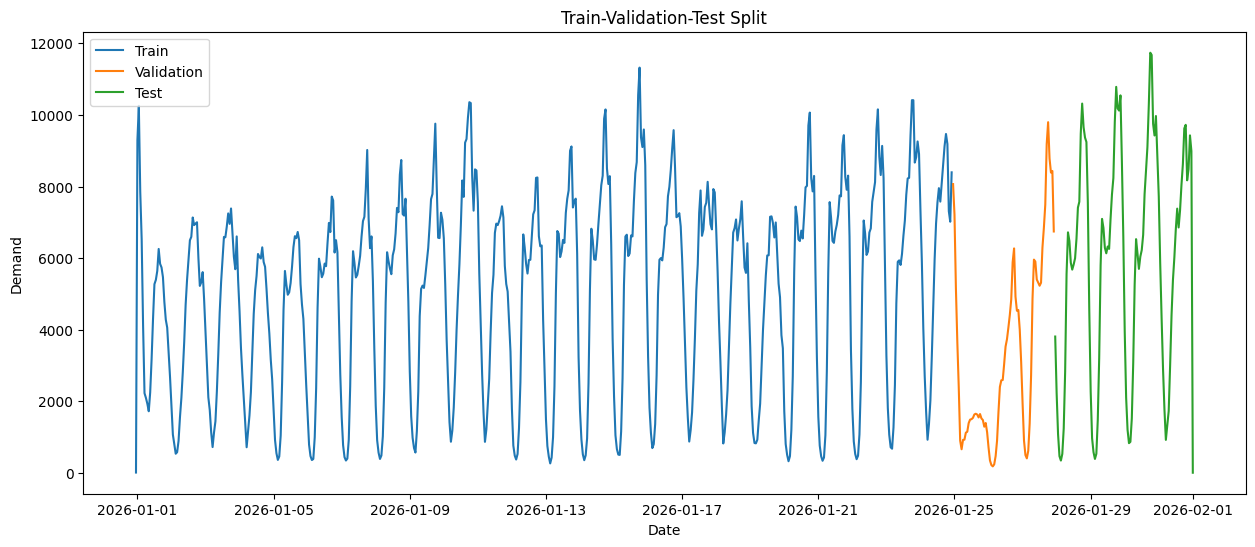

In [10]:
plt.figure(figsize=(15,6))

plt.plot(
    train.index,
    train['demand'],
    label='Train'
)

plt.plot(
    validation.index,
    validation['demand'],
    label='Validation'
)

plt.plot(
    test.index,
    test['demand'],
    label='Test'
)

plt.title(
    "Train-Validation-Test Split"
)

plt.xlabel("Date")

plt.ylabel("Demand")

plt.legend()

plt.show()

# Step 6:Train Initial SARIMA Model

## Purpose

Build the first SARIMA forecasting model using parameters identified in the previous notebook.

## Description

The model uses:

SARIMA(1,1,1)(1,1,1,24)

This configuration was selected based on:

- ADF Test
- ACF Analysis
- PACF Analysis
- Seasonal Pattern Analysis

## Expected Outcome

A trained SARIMA model capable of generating future demand forecasts.

In [11]:
model = SARIMAX(
    train['demand'],
    order=(1,1,1),
    seasonal_order=(1,1,1,24)
)

sarima_model = model.fit()

print("Model training completed.")

Model training completed.


# Step 7:Model Summary

## Purpose

Review the statistical details of the trained SARIMA model.

## Description

The summary provides information about:

- Model coefficients
- Statistical significance
- Information criteria
- Residual diagnostics

## Expected Outcome

Understand how well the model fits the historical demand series.

In [12]:
print(
    sarima_model.summary()
)

                                     SARIMAX Results                                      
Dep. Variable:                             demand   No. Observations:                  576
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 24)   Log Likelihood               -4369.204
Date:                            Mon, 08 Jun 2026   AIC                           8748.408
Time:                                    10:43:41   BIC                           8769.967
Sample:                                12-31-2025   HQIC                          8756.833
                                     - 01-24-2026                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0335      0.080      0.419      0.675      -0.123       0.190
ma.L1          0.4423      0.081   

## SARIMA Model Summary Interpretation

The SARIMA(1,1,1)(1,1,1,24) model successfully captured the daily seasonal structure present in hourly taxi demand data.

Key observations:

- The seasonal autoregressive component (AR.S.L24) is highly significant, indicating that demand from the same hour on the previous day contributes strongly to current demand.
- The seasonal moving average component is also significant, confirming the presence of strong daily seasonality.
- The non-seasonal AR component is not statistically significant, suggesting limited influence from the immediately preceding hour after differencing.
- The Ljung–Box test p-value (0.06) indicates that residual autocorrelation has largely been removed, implying that the model captures most temporal dependencies.
- Residual diagnostics reveal non-normality and changing variance over time, which is common in real-world taxi demand data due to peak-hour surges and irregular demand spikes.
- A covariance matrix warning suggests potential parameter instability and indicates that alternative SARIMA configurations should also be evaluated.

Overall, the model captures meaningful seasonal demand patterns and serves as a strong baseline forecasting model for hourly NYC taxi demand prediction.

---

# Step 8:# Evaluate Validation Forecast

## Purpose

Measure forecasting accuracy on unseen validation data.

## Description

Forecasts are compared against actual demand values using:

- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)

## Expected Outcome

Quantitative measures of forecasting performance are obtained.

In [13]:
validation_forecast = (
    sarima_model.forecast(
        steps=len(validation)
    )
)
mae = mean_absolute_error(
    validation['demand'],
    validation_forecast
)

rmse = np.sqrt(
    mean_squared_error(
        validation['demand'],
        validation_forecast
    )
)

print("Validation MAE :", mae)

print("Validation RMSE :", rmse)


Validation MAE : 5040.615114341191
Validation RMSE : 5442.098826303919


# Step 9:Compare Multiple SARIMA Models

## Purpose

Identify the best SARIMA configuration.

## Description

Several parameter combinations are tested and compared.

The model with the lowest forecasting error will be selected for final forecasting.

## Expected Outcome

A comparison table showing the performance of multiple SARIMA configurations.

In [14]:
candidates = [

    ((1,1,1),(1,1,1,24)),

    ((2,1,1),(1,1,1,24)),

    ((1,1,2),(1,1,1,24)),

    ((2,1,2),(1,1,1,24))

]

In [15]:
results = []

for order, seasonal in candidates:

    model = SARIMAX(
        train['demand'],
        order=order,
        seasonal_order=seasonal
    )

    fitted = model.fit(disp=False)

    forecast = fitted.forecast(
        steps=len(validation)
    )

    mae = mean_absolute_error(
        validation['demand'],
        forecast
    )

    rmse = np.sqrt(
        mean_squared_error(
            validation['demand'],
            forecast
        )
    )

    results.append([
        order,
        seasonal,
        mae,
        rmse,
        fitted.aic
    ])

In [16]:
comparison = pd.DataFrame(
    results,
    columns=[
        'Order',
        'Seasonal_Order',
        'MAE',
        'RMSE',
        'AIC'
    ]
)

comparison.sort_values(
    by='RMSE'
)

,Order,Seasonal_Order,MAE,RMSE,AIC
1,"(2, 1, 1)","(1, 1, 1, 24)",3017.243351,3669.873876,8686.383459
3,"(2, 1, 2)","(1, 1, 1, 24)",3022.262112,3673.990810,8687.108742
2,"(1, 1, 2)","(1, 1, 1, 24)",4950.772162,5360.543564,8750.351126
0,"(1, 1, 1)","(1, 1, 1, 24)",5040.615114,5442.098826,8748.408490


# Step 10:Select Best SARIMA Model

## Purpose

Choose the strongest forecasting model based on validation performance.

## Description

Models are ranked using evaluation metrics.

The best-performing configuration will be used for final forecasting.

## Expected Outcome

The optimal SARIMA configuration is identified.

In [17]:
best_model = (
    comparison
    .sort_values('RMSE')
    .iloc[0]
)

best_model

Order                 (2, 1, 1)
Seasonal_Order    (1, 1, 1, 24)
MAE                 3017.243351
RMSE                3669.873876
AIC                 8686.383459
Name: 1, dtype: object

# Step 11:Retrain Best Model

## Purpose

Train the selected SARIMA model using all available historical information before testing.

## Description

The training and validation datasets are combined to maximize the amount of information available for learning.

## Expected Outcome

A final optimized SARIMA model is created.

In [18]:
train_final = pd.concat(
    [train, validation]
)

best_order = (
    best_model['Order']
)

best_seasonal = (
    best_model['Seasonal_Order']
)

final_model = SARIMAX(
    train_final['demand'],
    order=best_order,
    seasonal_order=best_seasonal
)

final_model = final_model.fit()

# Step 12:Forecast Test Period

## Purpose

Generate demand forecasts for the final unseen test period.

## Description

The test set represents the most recent observations and simulates real-world future forecasting.

## Expected Outcome

Demand forecasts are generated for the test period.

In [19]:
test_forecast = (
    final_model.forecast(
        steps=len(test)
    )
)

# Step 13:Final Model Evaluation

## Purpose

Assess forecasting performance on completely unseen data.

## Description

Forecast accuracy is measured using:

- MAE
- RMSE

These metrics indicate how close predictions are to actual demand values.

## Expected Outcome

Reliable estimates of real-world forecasting performance.

In [20]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error


mae = mean_absolute_error(
    test['demand'],
    test_forecast
)

rmse = np.sqrt(
    mean_squared_error(
        test['demand'],
        test_forecast
    )
)

r2 = r2_score(
    test['demand'],
    test_forecast
)


print("Test MAE :", mae)

print("Test RMSE :", rmse)
print("Test R²  :", r2)

Test MAE : 1543.9302872712358
Test RMSE : 1914.8826713109859
Test R²  : 0.6455341054111603


# Step 14:Forecast vs Actual Comparison

## Purpose

Visually compare predicted demand against actual demand.

## Description

The graph helps identify:

- Forecast accuracy
- Trend alignment
- Seasonal pattern capture
- Prediction errors

## Expected Outcome

A visual assessment of model forecasting performance.

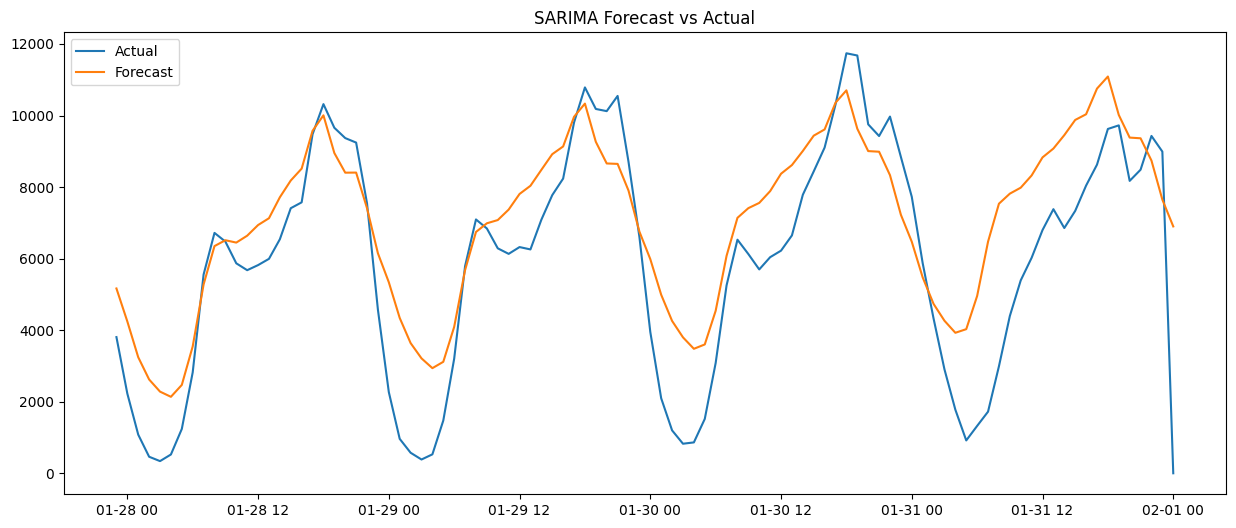

In [21]:
plt.figure(figsize=(15,6))

plt.plot(
    test.index,
    test['demand'],
    label='Actual'
)

plt.plot(
    test.index,
    test_forecast,
    label='Forecast'
)

plt.legend()

plt.title(
    "SARIMA Forecast vs Actual"
)

plt.show()

## Forecast vs Actual Demand

### Key Observations

- The SARIMA model successfully captures the **24-hour seasonal demand pattern**.
- Forecasted demand follows the overall trend of actual demand throughout the validation period.
- Peak demand timing is predicted accurately, indicating that recurring daily demand cycles are well learned.
- Forecast values are smoother than actual demand, showing that the model captures general patterns rather than short-term fluctuations.
- The largest prediction errors occur during sudden increases and decreases in demand.
- Low-demand periods are consistently overestimated, suggesting difficulty in modeling extreme demand drops.
- No significant forecast drift is observed, indicating stable model performance over time.

### Conclusion

The model effectively captures the dominant daily demand structure and provides reliable trend forecasts, but struggles with extreme peaks and troughs.

---

# Step 15:Residual Analysis

## Purpose

Evaluate the remaining prediction errors.

## Description

Residuals represent the difference between actual and predicted values.

A good forecasting model should produce residuals that are:

- Random
- Centered around zero
- Free from obvious patterns

## Expected Outcome

Validation that the model has captured most meaningful demand patterns.

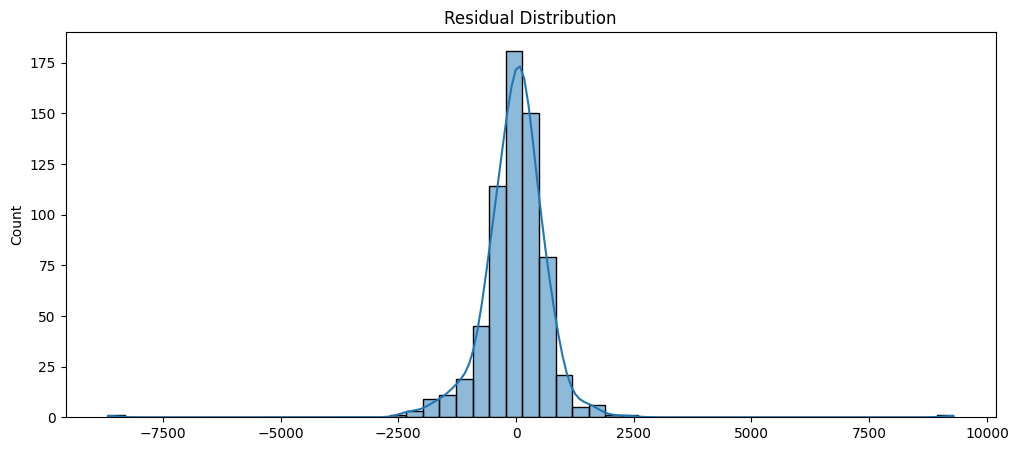

In [22]:
residuals = (
    final_model.resid
)

plt.figure(figsize=(12,5))

sns.histplot(
    residuals,
    kde=True
)

plt.title(
    "Residual Distribution"
)

plt.show()



## Residual Distribution

### Key Observations

- Residuals are centered around **zero**, indicating minimal prediction bias.
- The distribution is approximately bell-shaped, suggesting that most errors are random.
- Most residual values are concentrated near zero, indicating good forecast accuracy for the majority of observations.
- A few extreme positive and negative residuals exist, representing occasional large forecasting errors.
- The narrow spread of residuals indicates relatively stable prediction performance.
- No strong skewness is visible, suggesting balanced overprediction and underprediction behavior.

### Conclusion

The residual distribution indicates that the SARIMA model has captured most meaningful demand patterns, with remaining errors appearing largely random rather than systematic.

----

In [23]:
print(
    residuals.describe()
)

count     648.000000
mean      -10.882636
std       779.243453
min     -8666.021203
25%      -319.228225
50%        29.570219
75%       328.361604
max      9287.339294
dtype: float64


# Step 16:Residual Autocorrelation Check

## Purpose

Verify whether the SARIMA model has successfully captured the temporal patterns present in the demand series.

## Description

Residuals should behave like random noise after a good forecasting model is fitted.

The ACF plot of residuals helps identify whether any significant autocorrelation remains.

If strong autocorrelation still exists, the model may not have fully captured the underlying demand patterns.

## Expected Outcome

Most residual autocorrelation values should lie within the confidence intervals, indicating that the remaining errors are random and no major temporal structure is left unexplained.

---

<Figure size 1200x500 with 0 Axes>

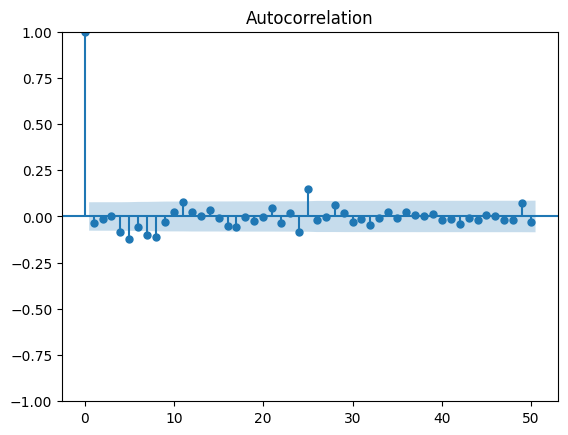

In [37]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12,5))

plot_acf(
    residuals,
    lags=50
)

plt.show()

### Observation

The residual ACF plot shows that almost all autocorrelation values fall within the confidence intervals.

Only a few minor spikes are visible, but no strong or persistent autocorrelation pattern remains.

The residual autocorrelation values are generally close to zero across most lags, indicating that the SARIMA model has successfully captured the temporal dependencies present in the demand series.

No significant seasonal spikes remain at lag 24 or other important lags, suggesting that the daily seasonal structure has been effectively modeled.

Overall, the residuals behave approximately like random noise rather than a structured time series.

---

# Step 17:Forecast Error Distribution

## Purpose

Analyze the distribution of forecasting errors generated by the final SARIMA model.

## Description

Forecast errors are calculated as:

Error = Actual Demand − Forecasted Demand

Examining the error distribution helps determine whether the model systematically overestimates or underestimates demand.

A well-performing forecasting model should produce errors that are centered around zero and approximately symmetric.

## Expected Outcome

The error distribution should be centered near zero with no strong skewness, indicating that the model predictions are generally unbiased and consistent.

---

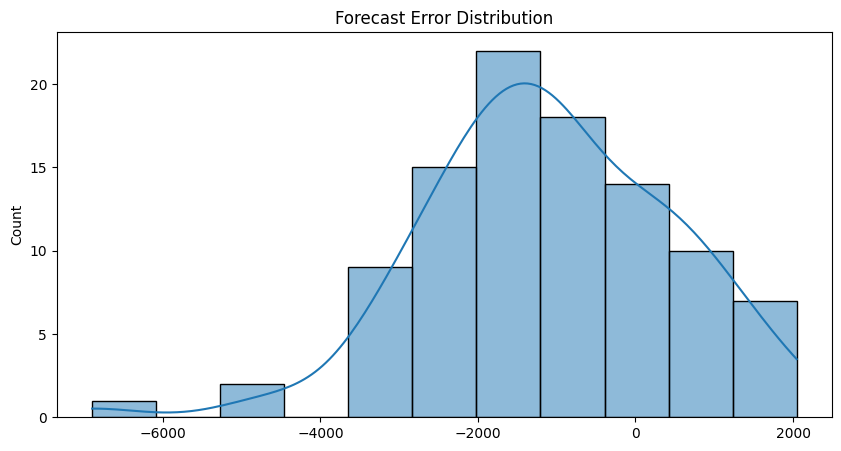

In [38]:
forecast_errors = (
    test['demand']
    - test_forecast
)

plt.figure(figsize=(10,5))

sns.histplot(
    forecast_errors,
    kde=True
)

plt.title(
    "Forecast Error Distribution"
)

plt.show()

### Observation

The forecast error distribution is approximately bell-shaped and concentrated around a central value.

Most prediction errors fall between approximately -3000 and +1500 trips, with the highest concentration occurring around -1500 trips.

The distribution appears slightly shifted toward negative values rather than being perfectly centered at zero.

This suggests that the model tends to underestimate demand more often than it overestimates demand.

A small number of larger negative errors are also visible, indicating occasional periods where actual demand exceeded the forecast by a substantial margin.

Despite this slight bias, the overall distribution remains reasonably smooth and does not show multiple peaks or unusual patterns.

# Step 18:Save Trained Model

## Purpose

Store the final SARIMA model for future forecasting and deployment.

## Description

Saving the model avoids retraining and enables direct use in future notebooks, dashboards, or applications.

## Expected Outcome

The trained SARIMA model is saved successfully.

In [39]:
import joblib

joblib.dump(
    final_model,
    "/home/ed/Desktop/NYC_Taxi_Demand_Forecasting/Yellow_Dataset/models/sarimax_model.pkl"
)

print("SARIMAX model saved successfully.")

SARIMAX model saved successfully.
